# Quantium Retail Analytics - Task 2
## Store Trial Analysis: New layout impact on Chip Sales

This notebook evaluates the effect of a new store layout on stores 77, 86, and 88 during February to April 2019. The goal is to anaylze if the implementation of a new store layout would meaningfully impact chip sales.

#### Process:
1) Select control stores that closely match the trial store's behavior
2) Compare trial store performance against control stores during the trial period
3) Use confidence intervals to test for statistical significance 
4) Identify possible drivers behind any change in sales

In [37]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
sns.set(color_codes=True)

df = pd.read_csv('QVI_data.csv')
print(df.dtypes)
df['DATE'] = pd.to_datetime(df['DATE'])
print('\nUpdated data types:', df.dtypes)

print(df.shape)

LYLTY_CARD_NBR        int64
DATE                 object
STORE_NBR             int64
TXN_ID                int64
PROD_NBR              int64
PROD_NAME            object
PROD_QTY              int64
TOT_SALES           float64
PACK_SIZE             int64
BRAND                object
LIFESTAGE            object
PREMIUM_CUSTOMER     object
dtype: object

Updated data types: LYLTY_CARD_NBR               int64
DATE                datetime64[ns]
STORE_NBR                    int64
TXN_ID                       int64
PROD_NBR                     int64
PROD_NAME                   object
PROD_QTY                     int64
TOT_SALES                  float64
PACK_SIZE                    int64
BRAND                       object
LIFESTAGE                   object
PREMIUM_CUSTOMER            object
dtype: object
(264834, 12)


In [38]:
print(df.columns)


Index(['LYLTY_CARD_NBR', 'DATE', 'STORE_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE',
       'PREMIUM_CUSTOMER'],
      dtype='object')


## Monthly Analysis
Store performance summarized into monthly data for clearer analysis.
- Sales revenue per month
- Number of unique customers per month
- Average transactions per customer per month
Monthly data will be used to identify which stores behaved similarly to the trial stores before the trial.

In [39]:
# Break down of monthly sales of each store (Sales rev, number of customers, avg transactions per customer)
df['YEARMONTH'] = df['DATE'].dt.to_period('M')
monthly = df.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    {'TOT_SALES': 'sum', 'LYLTY_CARD_NBR': 'nunique','TXN_ID': 'nunique'}
).reset_index()
monthly['AVG_TRANSACTION_PER_CUSTOMER'] = monthly['TXN_ID'] / monthly['LYLTY_CARD_NBR']
print(monthly.head())
print()
monthly.columns = ['Store_num', 'YearMonth', 'Total_Sales','Num_Customers', 'Number of Transactions','Avg_Transaction_Per_Customer']
print(monthly.head())
print(monthly['YearMonth'].unique())

   STORE_NBR YEARMONTH  TOT_SALES  LYLTY_CARD_NBR  TXN_ID  \
0          1   2018-07      206.9              49      52   
1          1   2018-08      176.1              42      43   
2          1   2018-09      278.8              59      62   
3          1   2018-10      188.1              44      45   
4          1   2018-11      192.6              46      47   

   AVG_TRANSACTION_PER_CUSTOMER  
0                      1.061224  
1                      1.023810  
2                      1.050847  
3                      1.022727  
4                      1.021739  

   Store_num YearMonth  Total_Sales  Num_Customers  Number of Transactions  \
0          1   2018-07        206.9             49                      52   
1          1   2018-08        176.1             42                      43   
2          1   2018-09        278.8             59                      62   
3          1   2018-10        188.1             44                      45   
4          1   2018-11        192.6   

In [40]:
# Create measure to compare the different control stores to the trial stores
trial_stores = [77, 86, 88]
print(monthly[monthly['Store_num'].isin(trial_stores)][['Store_num', 'YearMonth', 'Total_Sales']])
print()



      Store_num YearMonth  Total_Sales
880          77   2018-07       296.80
881          77   2018-08       255.50
882          77   2018-09       225.20
883          77   2018-10       204.50
884          77   2018-11       245.30
885          77   2018-12       267.30
886          77   2019-01       204.40
887          77   2019-02       235.00
888          77   2019-03       278.50
889          77   2019-04       263.50
890          77   2019-05       299.30
891          77   2019-06       264.70
977          86   2018-07       892.20
978          86   2018-08       764.05
979          86   2018-09       914.60
980          86   2018-10       948.40
981          86   2018-11       918.00
982          86   2018-12       841.20
983          86   2019-01       841.40
984          86   2019-02       913.20
985          86   2019-03      1026.80
986          86   2019-04       848.20
987          86   2019-05       889.30
988          86   2019-06       838.00
1001         88   2018-07

### Control Store Selection
Need to find control stores that closely match each trial store (77, 86, 88) in terms of the pre-trial behavior. Pre trial period consists of July 2019 to January 2019.

In [41]:
#Pre trial period
pre_trial = monthly[monthly['YearMonth'] < '2019-02']
sales_pivot = pre_trial.pivot(index='YearMonth', columns='Store_num', values='Total_Sales')
print(sales_pivot.head())
print(sales_pivot.shape)

Store_num    1      2        3       4      5      6       7      8      9    \
YearMonth                                                                      
2018-07    206.9  150.8  1205.70  1399.9  812.0  260.0  1024.7  381.6  289.7   
2018-08    176.1  193.8  1079.75  1259.5  745.1  203.2  1119.9  383.0  327.5   
2018-09    278.8  154.4  1021.50  1198.6  896.0  207.7  1147.3  293.0  369.7   
2018-10    188.1  167.8  1037.90  1346.4  798.0  292.4  1063.9  422.8  361.0   
2018-11    192.6  162.9  1008.00  1212.0  771.4  255.3  1076.5  349.2  374.4   

Store_num     10   ...   263    264    265    266   267     268     269  \
YearMonth          ...                                                    
2018-07    892.00  ...  38.7  232.6  247.8  127.3   6.2  224.00   982.0   
2018-08    878.65  ...  28.0  203.3  227.1  154.5  24.9  322.65   835.1   
2018-09    945.00  ...  21.8  199.5  133.5  139.0  23.3  174.40   886.0   
2018-10    910.80  ...  36.6  170.0  162.9  170.4  14.4  237.60 

### Pearson Correlation
Pearson Correlation was implemented to calculate how closely each store's monthly sales pattern correlates with each trial store. A correlation closer to 1 would suggest stores behave similarly over time. 

In [42]:
# Pearson correlation of the trial stores with the control stores to see which control store is most similar to the trial stores in the pre-trial period

# Drop stores with missing months
sales_pivot_clean = sales_pivot.dropna(axis=1)


for store in trial_stores:
    correlations = sales_pivot_clean.corrwith(sales_pivot_clean[store])
    correlations = correlations.drop(store)
    correlations = correlations.dropna() 
    correlations = correlations[correlations < 1.0]
    correlations = correlations.sort_values(ascending=False)
    print(f'\nTop 5 control store candidates for Store {store}:')
    print(correlations.head())


Top 5 control store candidates for Store 77:
Store_num
71     0.914106
233    0.903774
119    0.867664
17     0.842668
3      0.806644
dtype: float64

Top 5 control store candidates for Store 86:
Store_num
155    0.877882
132    0.846517
240    0.825066
222    0.795075
109    0.788300
dtype: float64

Top 5 control store candidates for Store 88:
Store_num
159    0.903186
204    0.885774
134    0.864293
1      0.813636
253    0.811838
dtype: float64


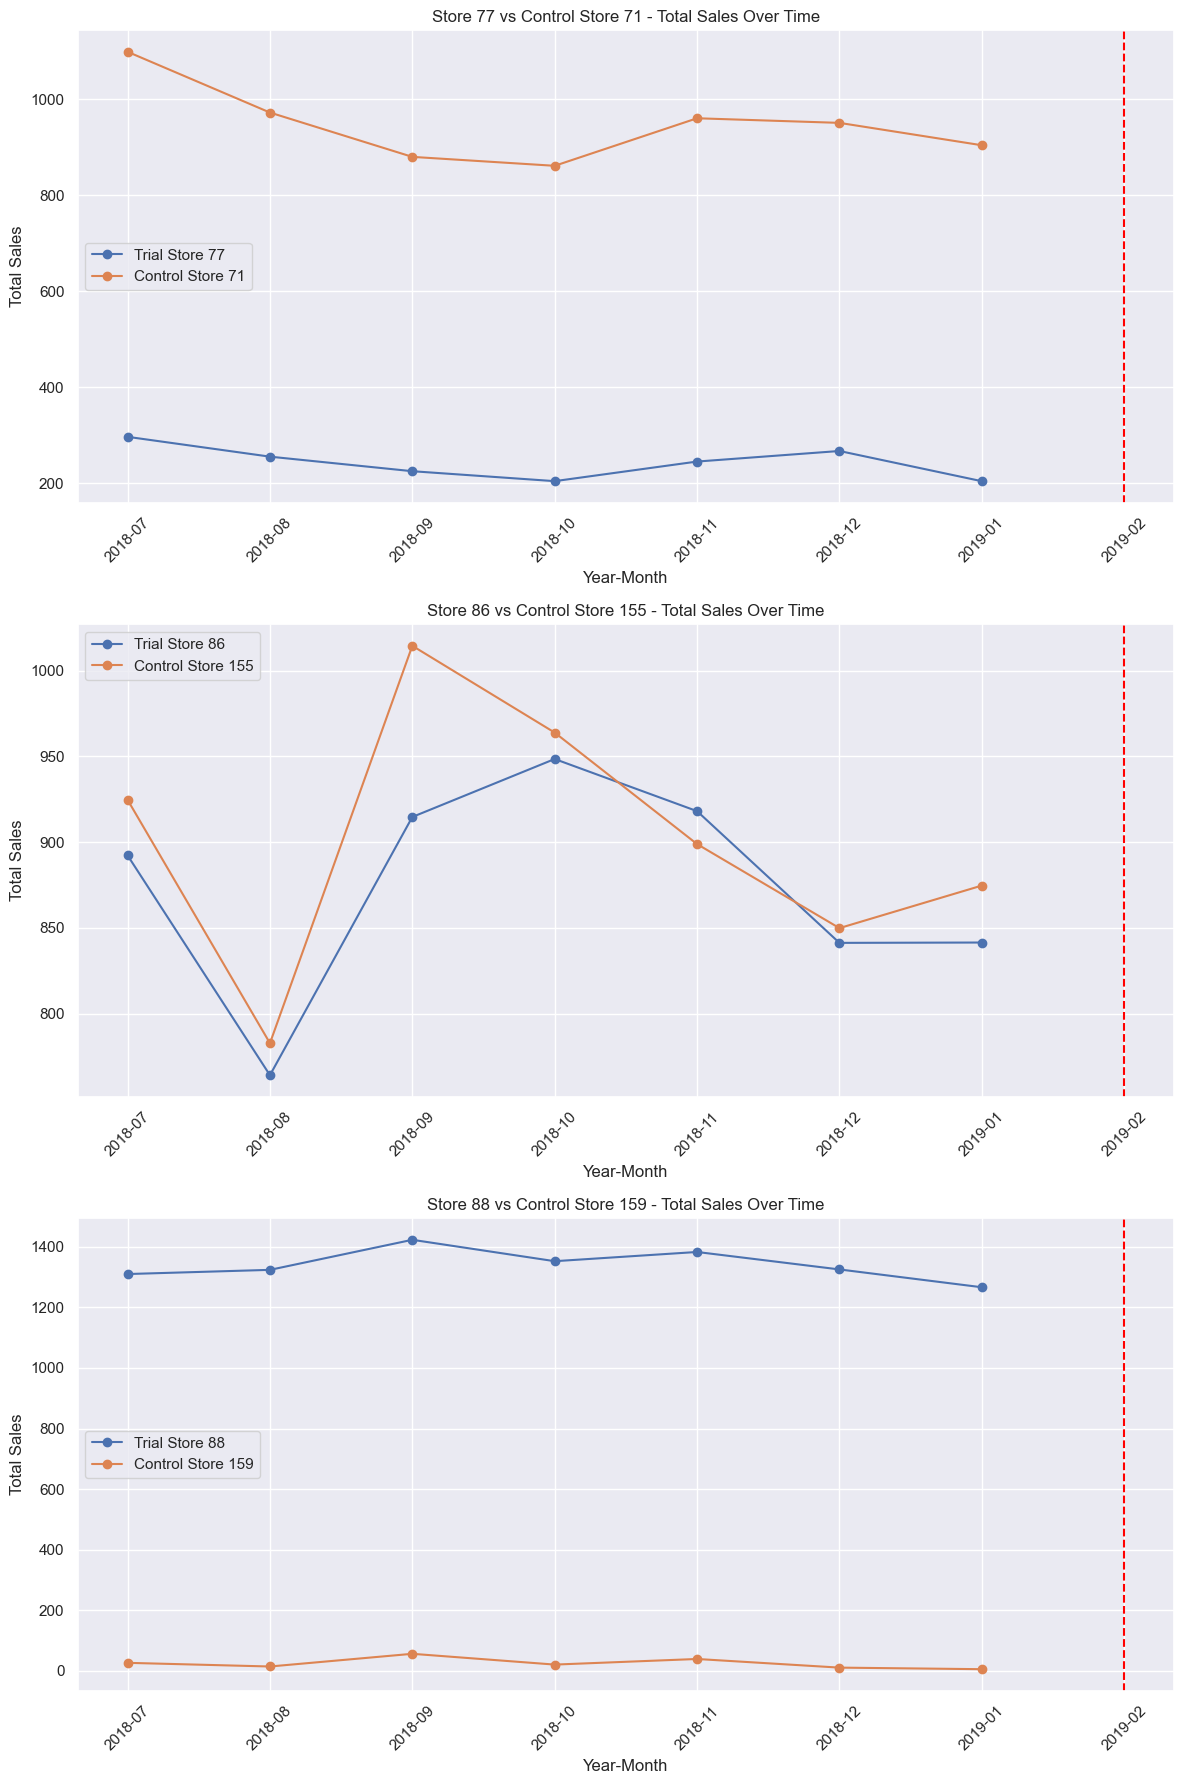

In [43]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
control_pairs = [(77, 71), (86, 155), (88, 159)]
for i, (trial_store, control_store) in enumerate(control_pairs):
    trial_data = sales_pivot[trial_store]
    control_data = sales_pivot[control_store]
    
    axes[i].plot(trial_data.index.astype(str), trial_data.values, label=f'Trial Store {trial_store}', marker='o')
    axes[i].plot(control_data.index.astype(str), control_data.values, label=f'Control Store {control_store}', marker='o')
    
    axes[i].set_title(f'Store {trial_store} vs Control Store {control_store} - Total Sales Over Time')
    axes[i].set_xlabel('Year-Month')
    axes[i].set_ylabel('Total Sales')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axvline(x='2019-02', color='red', linestyle='--', label='Trial Start')

plt.tight_layout()
plt.show()
 

### Visible Issue
Although the Pearson Correlation provides the best match in terms of sales trend, the plots show differences in sales volume, specifically for stores 77 and 88. To further improve control over the appropriate store, a size filter was added to account for the possibility that the size of the store plays a role in sales volume. 


In [44]:
pre_trial_avg = sales_pivot_clean.mean()

for store in [77, 88]:
    avg = pre_trial_avg[store]
    similar_size = pre_trial_avg[
        (pre_trial_avg >= avg * 0.8) & 
        (pre_trial_avg <= avg * 1.2)
    ].index.tolist()
    
    # Remove the trial store itself
    similar_size = [s for s in similar_size if s != store]
    
    # Correlation within similar sized stores only
    correlations = sales_pivot_clean[similar_size].corrwith(sales_pivot_clean[store])
    correlations = correlations[correlations < 1.0].dropna()
    correlations = correlations.sort_values(ascending=False)
    print(f'\nTop 5 control candidates for Store {store} (size + correlation):')
    print(correlations.head())


Top 5 control candidates for Store 77 (size + correlation):
Store_num
233    0.903774
41     0.783232
50     0.763866
265    0.639759
53     0.532764
dtype: float64

Top 5 control candidates for Store 88 (size + correlation):
Store_num
125    0.624109
203    0.508001
201    0.492735
123    0.399761
217    0.347041
dtype: float64


### Final Control Store Pairs
After taking into account size and correlation our final control store selections are:
- Store 77 -> Control Store 233
- Store 86 -> Control Store 155  
- Store 88 -> Control Store 237

The charts below confirm that each pair tracked closely in the pre-trial period, validating our control store selection.

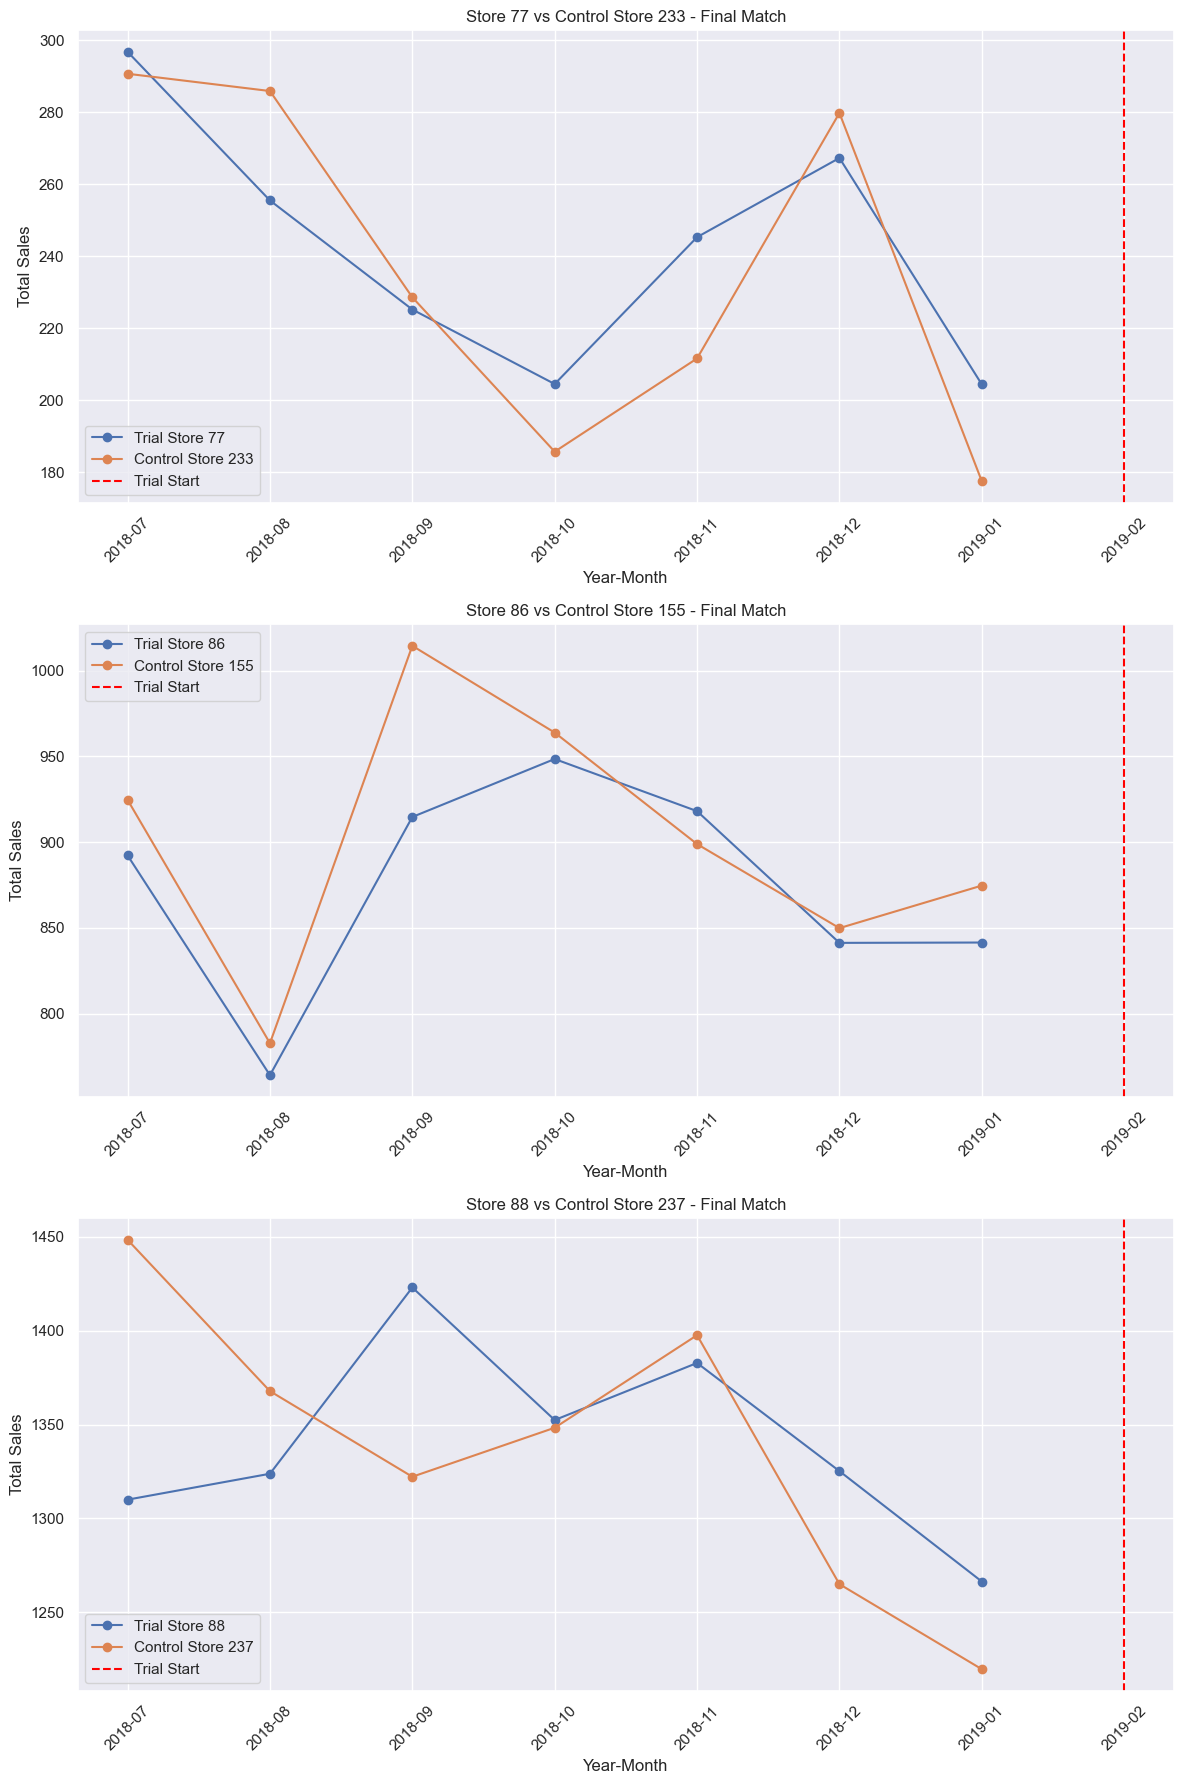

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
control_pairs = [(77, 233), (86, 155), (88, 237)]

for i, (trial_store, control_store) in enumerate(control_pairs):
    trial_data = sales_pivot[trial_store]
    control_data = sales_pivot[control_store]
    
    axes[i].plot(trial_data.index.astype(str), trial_data.values, 
                 label=f'Trial Store {trial_store}', marker='o')
    axes[i].plot(control_data.index.astype(str), control_data.values, 
                 label=f'Control Store {control_store}', marker='o')
    axes[i].axvline(x='2019-02', color='red', linestyle='--', label='Trial Start')
    axes[i].set_title(f'Store {trial_store} vs Control Store {control_store} - Final Match')
    axes[i].set_xlabel('Year-Month')
    axes[i].set_ylabel('Total Sales')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Trial Assessment

Now we compare each trial store against its matched control store during the trial period (February to April 2019).

The control store sales are scaled to match the trial store's pre-trial baseline — this removes any remaining size difference  between the two stores so that any gap during the trial reflects the layout change rather than pre-existing differences.

A 95% confidence interval is built from the natural variation between the two stores in the pre-trial period. If the trial store's sales fall outside this band during the trial months, the difference is statistically significant.

In [46]:
# Trial Assessment
trial_period = ['2019-02', '2019-03', '2019-04']
pre_trial_period =['2018-07', '2018-08', '2018-09', 
                    '2018-10', '2018-11', '2018-12', '2019-01']


for trial_store, control_store in control_pairs:
    trial_sales = monthly[monthly['Store_num'] == trial_store].set_index('YearMonth')['Total_Sales']
    control_sales = monthly[monthly['Store_num'] == control_store].set_index('YearMonth')['Total_Sales']

    scaling_factor = trial_sales[pre_trial_period].sum() / control_sales[pre_trial_period].sum()
    scaled_control = control_sales * scaling_factor
    
    pct_diff = abs(trial_sales - scaled_control) / scaled_control
    std_dev = pct_diff[pre_trial_period].std()
    
    upper = scaled_control * (1 + std_dev * 2)
    lower = scaled_control * (1 - std_dev * 2)
    
    print(f'\nStore {trial_store} vs Control {control_store}')
    print('Trial period % difference:')
    print(pct_diff[trial_period])
    print(f'Std dev (pre-trial): {std_dev:.4f}')
    print('Trial store outside 95% CI:')
    print((trial_sales[trial_period] > upper[trial_period]) | 
          (trial_sales[trial_period] < lower[trial_period]))



Store 77 vs Control 233
Trial period % difference:
YearMonth
2019-02    0.059107
2019-03    0.366521
2019-04    0.623080
Freq: M, Name: Total_Sales, dtype: float64
Std dev (pre-trial): 0.0499
Trial store outside 95% CI:
YearMonth
2019-02    False
2019-03     True
2019-04     True
Freq: M, Name: Total_Sales, dtype: bool

Store 86 vs Control 155
Trial period % difference:
YearMonth
2019-02    0.056306
2019-03    0.315870
2019-04    0.035253
Freq: M, Name: Total_Sales, dtype: float64
Std dev (pre-trial): 0.0258
Trial store outside 95% CI:
YearMonth
2019-02     True
2019-03     True
2019-04    False
Freq: M, Name: Total_Sales, dtype: bool

Store 88 vs Control 237
Trial period % difference:
YearMonth
2019-02    0.026147
2019-03    0.220743
2019-04    0.193060
Freq: M, Name: Total_Sales, dtype: float64
Std dev (pre-trial): 0.0335
Trial store outside 95% CI:
YearMonth
2019-02    False
2019-03     True
2019-04     True
Freq: M, Name: Total_Sales, dtype: bool


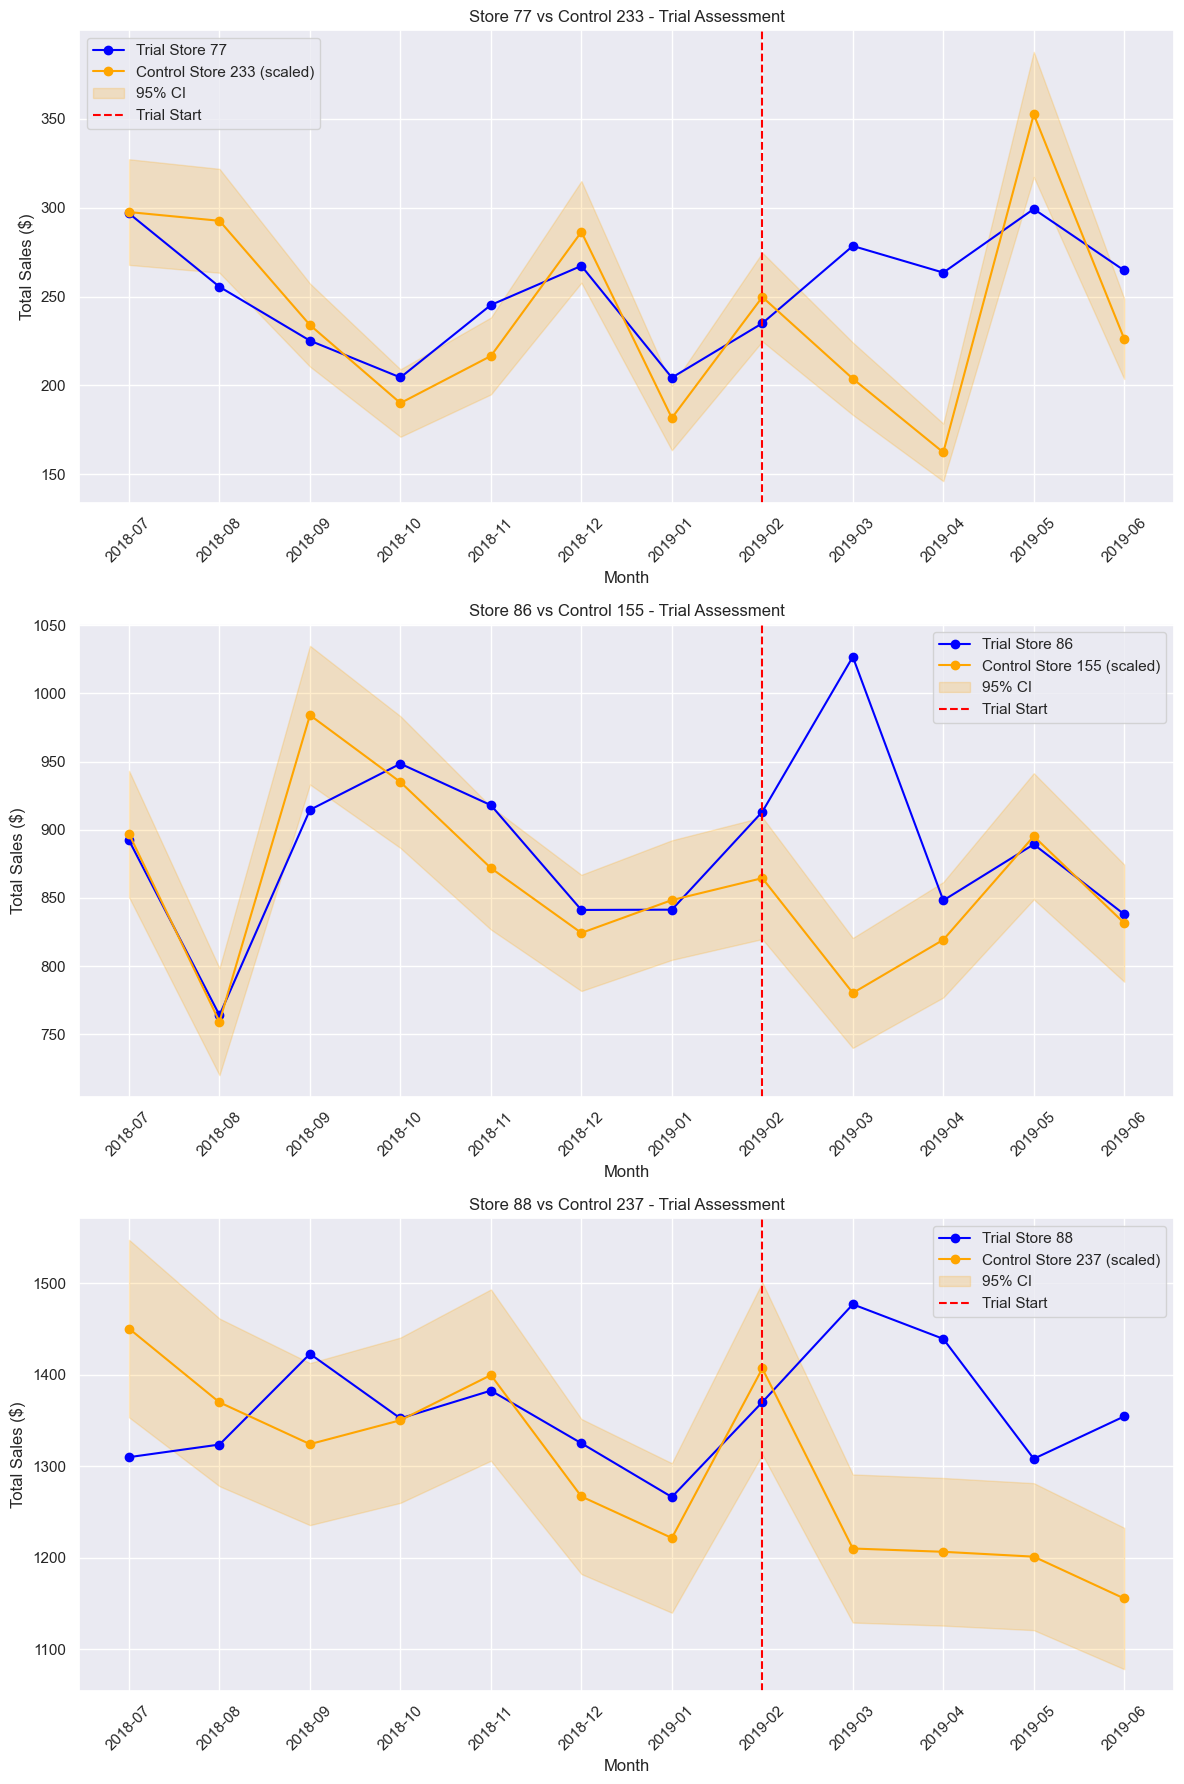

<Figure size 640x480 with 0 Axes>

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for i, (trial_store, control_store) in enumerate(control_pairs):
    trial_sales = monthly[monthly['Store_num'] == trial_store].set_index('YearMonth')['Total_Sales']
    control_sales = monthly[monthly['Store_num'] == control_store].set_index('YearMonth')['Total_Sales']
    
    scaling_factor = trial_sales[pre_trial_period].sum() / control_sales[pre_trial_period].sum()
    scaled_control = control_sales * scaling_factor
    
    pct_diff = abs(trial_sales - scaled_control) / scaled_control
    std_dev = pct_diff[pre_trial_period].std()
    
    upper = scaled_control * (1 + std_dev * 2)
    lower = scaled_control * (1 - std_dev * 2)
    
    months = trial_sales.index.astype(str)
    
    axes[i].plot(months, trial_sales.values, label=f'Trial Store {trial_store}', marker='o', color='blue')
    axes[i].plot(months, scaled_control.values, label=f'Control Store {control_store} (scaled)', marker='o', color='orange')
    axes[i].fill_between(months, lower.values, upper.values, alpha=0.2, color='orange', label='95% CI')
    axes[i].axvline(x='2019-02', color='red', linestyle='--', label='Trial Start')
    axes[i].set_title(f'Store {trial_store} vs Control {control_store} - Trial Assessment')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Total Sales ($)')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
plt.savefig('trial_assessment.png', bbox_inches='tight', dpi=150)

### Visual Analysis
These plots show the full sales timeline for each trial store paired with this control store. The control store sales have been scaled to match the respective trial store as form of a baseline level, which would allow us to hypothetically see how the sales would look like if nothing changed in the trial store. 
The orange shaded bands represent the 95% CI - the expected variation of sales between the two stores. For instance, if the trial store (blue line) were to stay within the bands, any difference would be considered normal variation, anything outside shows an impact in sales.

Store 77: The trial store shows that it breaks past the confidence bands in March and April of 2019, indicating that the new layout has positively affected chip sales.

Store 86: The trial store showed a significant spike in chip sales during March of 2019 following the new layout but returned back to normal the following months.

Store 88: The trial store followed similar behavior to that of store 77 but maintained its success in sales as the months went by, indicating that the new layout was successful.



### Driver Analysis

Having confirmed that the trial had a significant impact on sales in stores 77 and 88, we now investigate what drove the increase.
Two possible drivers:
- More customers visiting the store
- Existing customers buying more chips per visit

Understanding the driver matters because it changes the recommendation — attracting new customers vs influencing 
existing buying behavior require different strategies.

In [48]:
# Customer count and avg transactions per customer assessment throughout the trial period
for trial_store, control_store in control_pairs:
    trial_custs = monthly[monthly['Store_num'] == trial_store].set_index('YearMonth')['Num_Customers']
    control_custs = monthly[monthly['Store_num'] == control_store].set_index('YearMonth')['Num_Customers']
    
    trial_txn = monthly[monthly['Store_num'] == trial_store].set_index('YearMonth')['Avg_Transaction_Per_Customer']
    control_txn = monthly[monthly['Store_num'] == control_store].set_index('YearMonth')['Avg_Transaction_Per_Customer']
    
    # Scale customers
    scaling_factor_custs = trial_custs[pre_trial_period].sum() / control_custs[pre_trial_period].sum()
    scaled_control_custs = control_custs * scaling_factor_custs
    
    # Scale transactions
    scaling_factor_txn = trial_txn[pre_trial_period].sum() / control_txn[pre_trial_period].sum()
    scaled_control_txn = control_txn * scaling_factor_txn
    
    # % difference during trial
    pct_diff_custs = abs(trial_custs - scaled_control_custs) / scaled_control_custs
    pct_diff_txn = abs(trial_txn - scaled_control_txn) / scaled_control_txn
    
    print(f'\nStore {trial_store} vs Control {control_store}')
    print('Customer count % difference during trial:')
    print(pct_diff_custs[trial_period])
    print('Avg transactions per customer % difference during trial:')
    print(pct_diff_txn[trial_period])


Store 77 vs Control 233
Customer count % difference during trial:
YearMonth
2019-02    0.003344
2019-03    0.245819
2019-04    0.561427
Freq: M, Name: Num_Customers, dtype: float64
Avg transactions per customer % difference during trial:
YearMonth
2019-02    0.057547
2019-03    0.056365
2019-04    0.057547
Freq: M, Name: Avg_Transaction_Per_Customer, dtype: float64

Store 86 vs Control 155
Customer count % difference during trial:
YearMonth
2019-02    0.126316
2019-03    0.223404
2019-04    0.060606
Freq: M, Name: Num_Customers, dtype: float64
Avg transactions per customer % difference during trial:
YearMonth
2019-02    0.006959
2019-03    0.003726
2019-04    0.017040
Freq: M, Name: Avg_Transaction_Per_Customer, dtype: float64

Store 88 vs Control 237
Customer count % difference during trial:
YearMonth
2019-02    0.010281
2019-03    0.132448
2019-04    0.072727
Freq: M, Name: Num_Customers, dtype: float64
Avg transactions per customer % difference during trial:
YearMonth
2019-02    0.

### Driver Evaluation: Why was the new layout successful?
Following the assessment that new layouts overall improved chip sales in the trial stores, a deeper investigation to identify what specifically was behind the success was done with the possibility that new layouts brought more customers or made existing customers buy more chips per visit.

Store 77: Driver -> New Customers
Store 77 showed clear growth in customer count during the trial, growing from .3% in February to 56% by April compared to its control store. Average transaction per customer remained constant throughout the trial. Results indicate that the layout did not change buying bahavior but it did attract more customers to the store.

Store 86: Driver -> Short lived effect
Store 86 saw a spike in number of customers in March at 22% but settled at 6% in April. Transactions per customer showed a small improvement in buying behavior but nothing meaningful. Results align with the sales plot where March spiked above the Confidence bounds, with it falling within the bounds in the following months, suggesting the new layout had a short lived effect on the store.

Store 88: Driver -> New Customers and More Transactions
Store 88 saw moderate customer growth in the trial period with 13% growth in March. However, average transactions per customer grew significantly from 2% to 11%, meaning that existing customers also bought more chips during thier visit. The results indicate that the new layout brought new customers but also influenced purchasing behavior, indicating success.

### Recommendation
The new store layouts show a positive effect on chip sales and should be considered in all stores. All three stores showed no negative impact that the layout may have, with store 77 and store 88 showing success. 
This analysis showed that the new store layout brings an increasement in customer count and an influence in purchasing behavior for existing customers.